# Notebook for Batch Loading, Sorting, and Averaging G(r) by Temperature

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import trxrd

%matplotlib widget

## Define Path and Scan Name

Filenames are expected to follow the pattern:
`{sample_name}{temperature}K{fluence}fshw{delay}delay{scan_number}_{image_number}.gr`

For example: `BTO400S3_staticTdep240K-1.0fshw1e-09delay00000_077.gr`

Set `SAMPLE_NAME` to the base prefix **before** the temperature (e.g. `"BTO400S3_staticTdep"`).

In [2]:
DATA_PATH   = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO_Temp_Data")
SAMPLE_NAME = "BTO400nmS3_"   # base prefix before temperature, e.g. "BTO400S3_staticTdep"

## Load I(Q) Data

In [3]:
dat_dict = trxrd.get_dat_details(
    folder_path=DATA_PATH,
    sample_name=SAMPLE_NAME,
    filename_scheme="temp_dep",
    sort=True,
    sort_key="temperature",
    filter_data=False,
    plot=False,
)


q = dat_dict["q"]            # shape (Nr,)
iq = dat_dict["iqs"]          # shape (Nfiles, Nr)
temperature = dat_dict["temperature"]  # shape (Nfiles,) in Kelvin

print(f"Loaded {len(iq)} .dat files")
print(f"Unique temperatures (K): {sorted(np.unique(temperature).astype(int))}")

88 .dat files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO_Temp_Data
Loaded 79 .dat files
Unique temperatures (K): [np.int64(240), np.int64(260), np.int64(280), np.int64(300), np.int64(320), np.int64(340), np.int64(360), np.int64(380)]


## Average I(Q) by Temperature

In [4]:
avg_iq_dict = trxrd.average_iqs_by_temperature(dat_dict, return_dict=True)

print(avg_iq_dict.keys())
print("Averaged I(q) shape:", avg_iq_dict["iqs"].shape)
print("Std I(q) shape:",      avg_iq_dict["std_iqs"].shape)
print("Unique temperatures (K):", avg_iq_dict["temperature"].astype(int))
print("Counts per temperature:", avg_iq_dict["counts_per_temp"])

dict_keys(['iqs', 'std_iqs', 'temperature', 'counts_per_temp', 'indices_by_temp', 'grouped_file_names', 'grouped_scan_numbers', 'q'])
Averaged I(q) shape: (8, 3000)
Std I(q) shape: (8, 3000)
Unique temperatures (K): [240 260 280 300 320 340 360 380]
Counts per temperature: [10 10 10 10  9 10 10 10]


## Plot Temperature-Dependent I(Q)

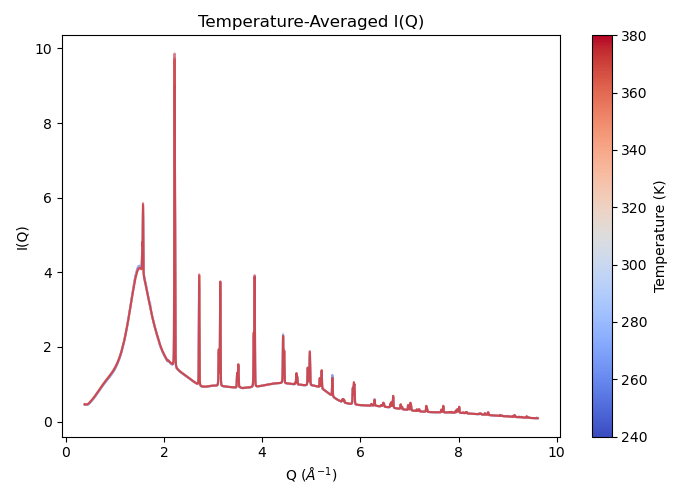

In [8]:
temps = avg_iq_dict["temperature"]   # unique temperatures in K
mean_iqs = avg_iq_dict["iqs"]

norm = mcolors.Normalize(vmin=temps.min(), vmax=temps.max())
cmap = cm.coolwarm

fig, ax = plt.subplots(figsize=(7, 5))

for i, T in enumerate(temps):
    ax.plot(
        avg_iq_dict["q"],
        mean_iqs[i],
        color=cmap(norm(T)),
        alpha=0.5,
        linewidth=1.5,
        label=f"{int(T)} K",
    )

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Temperature (K)")

ax.set_xlabel(r"Q ($\AA^{-1}$)")
ax.set_ylabel("I(Q)")
ax.set_title("Temperature-Averaged I(Q)")
plt.tight_layout()
plt.show()

## Compute dI(Q) Relative to a Reference Temperature

Subtract the I(Q) at the lowest (or user-chosen) temperature to highlight structural changes.

In [9]:
# Choose reference temperature (default: lowest T)
REF_TEMP = temps.min()   # change to e.g. 240 to use a specific temperature
#REF_TEMP = 260

ref_idx = np.where(temps == REF_TEMP)[0][0]
reference_iq = mean_iqs[ref_idx]

delta_iqs = mean_iqs - reference_iq   # shape (n_temps, Nr)

print(f"Reference temperature: {int(REF_TEMP)} K")
print(f"dI(Q) shape: {delta_iqs.shape}")

Reference temperature: 240 K
dI(Q) shape: (8, 3000)


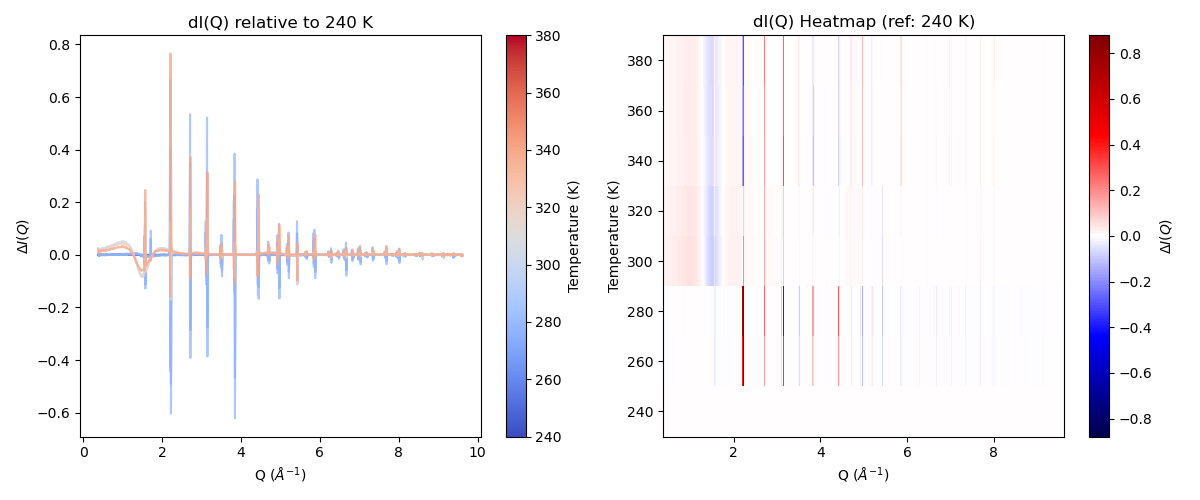

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Waterfall of dG(r) vs temperature
norm_dg = mcolors.Normalize(vmin=temps.min(), vmax=temps.max())
for i, T in enumerate(temps[:-2]):
    axes[0].plot(
        avg_iq_dict["q"],
        delta_iqs[i],
        color=cmap(norm_dg(T)),
        alpha=0.8,
        linewidth=1.5,
        label=f"{int(T)} K",
    )

# axes[0].plot(avg_iq_dict["q"], reference_iq/50+0.05, color="gray", linestyle="--", linewidth=1)
sm2 = cm.ScalarMappable(norm=norm_dg, cmap=cmap)
sm2.set_array([])
fig.colorbar(sm2, ax=axes[0], label="Temperature (K)")
axes[0].set_xlabel(r"Q ($\AA^{-1}$)")
axes[0].set_ylabel(r"$\Delta I(Q)$")
axes[0].set_title(f"dI(Q) relative to {int(REF_TEMP)} K")

# Heatmap of dI(Q) vs temperature
vmax = np.nanmax(np.abs(delta_iqs))
pcm = axes[1].pcolormesh(
    avg_iq_dict["q"],
    temps,
    delta_iqs,
    shading="auto",
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
)
fig.colorbar(pcm, ax=axes[1], label=r"$\Delta I(Q)$")
axes[1].set_xlabel(r"Q ($\AA^{-1}$)")
axes[1].set_ylabel("Temperature (K)")
axes[1].set_title(f"dI(Q) Heatmap (ref: {int(REF_TEMP)} K)")


plt.tight_layout()
plt.show()

## Compute dI(Q) Between Consecutive Temperatures

Subtract each temperature's I(Q) from the next: I(T+ΔT) − I(T), i.e. 260−240, 280−260, 300−280, …

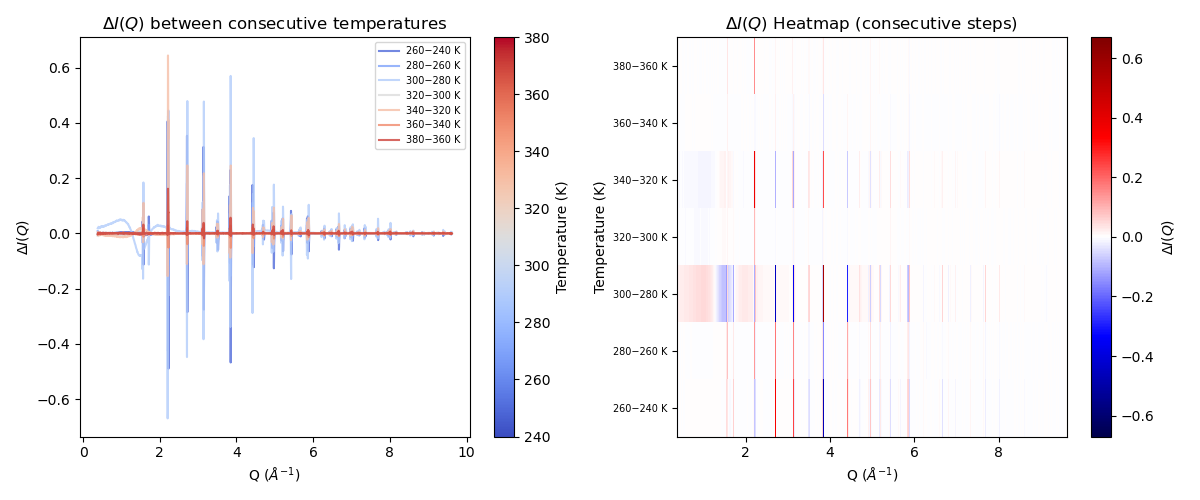

In [15]:
# Consecutive dI(Q): each step minus the previous temperature
consec_delta_iqs = mean_iqs[1:] - mean_iqs[:-1]   # shape (n_temps-1, Nr)
consec_temps = avg_iq_dict["temperature"]   # use the per-scan temps array (still valid here)

# Build labels and mid-point temperatures for coloring
step_labels = [f"{int(temps[i+1])}−{int(temps[i])} K" for i in range(len(temps) - 1)]
mid_temps   = (temps[:-1] + temps[1:]) / 2

norm_consec = mcolors.Normalize(vmin=temps.min(), vmax=temps.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Waterfall ---
for i, label in enumerate(step_labels):
    axes[0].plot(
        avg_iq_dict["q"],
        consec_delta_iqs[i],
        color=cmap(norm_consec(mid_temps[i])),
        alpha=0.8,
        linewidth=1.5,
        label=label,
    )

sm3 = cm.ScalarMappable(norm=norm_consec, cmap=cmap)
sm3.set_array([])
fig.colorbar(sm3, ax=axes[0], label="Temperature (K)")
axes[0].set_xlabel(r"Q ($\AA^{-1}$)")
axes[0].set_ylabel(r"$\Delta I(Q)$")
axes[0].set_title(r"$\Delta I(Q)$ between consecutive temperatures")
axes[0].legend(fontsize=7, loc="upper right")

# --- Heatmap ---
vmax_c = np.nanmax(np.abs(consec_delta_iqs))
pcm2 = axes[1].pcolormesh(
    avg_iq_dict["q"],
    mid_temps,
    consec_delta_iqs,
    shading="auto",
    cmap="seismic",
    vmin=-vmax_c,
    vmax=vmax_c,
)
fig.colorbar(pcm2, ax=axes[1], label=r"$\Delta I(Q)$")
axes[1].set_xlabel(r"Q ($\AA^{-1}$)")
axes[1].set_ylabel("Temperature (K)")
axes[1].set_title(r"$\Delta I(Q)$ Heatmap (consecutive steps)")
axes[1].set_yticks(mid_temps)
axes[1].set_yticklabels(step_labels, fontsize=7)

plt.tight_layout()
plt.show()

## Load G(r) Data

In [12]:
gr_dict = trxrd.get_gr_details(
    folder_path=DATA_PATH,
    sample_name=SAMPLE_NAME,
    filename_scheme="temp_dep",
    sort=True,
    sort_key="temperature",
    filter_data=False,
    plot=False,
)

r           = gr_dict["r"]            # shape (Nr,)
grs         = gr_dict["grs"]          # shape (Nfiles, Nr)
temperature = gr_dict["temperature"]  # shape (Nfiles,) in Kelvin

print(f"Loaded {len(grs)} .gr files")
print(f"Unique temperatures (K): {sorted(np.unique(temperature).astype(int))}")

8 .gr files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO_Temp_Data
Loaded 8 .gr files
Unique temperatures (K): [np.int64(240), np.int64(260), np.int64(280), np.int64(300), np.int64(320), np.int64(340), np.int64(360), np.int64(380)]


## Average G(r) by Temperature

In [13]:
avg_gr_dict = trxrd.average_grs_by_temperature(gr_dict, return_dict=True)

print(avg_gr_dict.keys())
print("Averaged G(r) shape:", avg_gr_dict["grs"].shape)
print("Std G(r) shape:",      avg_gr_dict["std_grs"].shape)
print("Unique temperatures (K):", avg_gr_dict["temperature"].astype(int))
print("Counts per temperature:", avg_gr_dict["counts_per_temp"])

dict_keys(['grs', 'std_grs', 'temperature', 'counts_per_temp', 'indices_by_temp', 'grouped_file_names', 'grouped_scan_numbers', 'r'])
Averaged G(r) shape: (8, 3001)
Std G(r) shape: (8, 3001)
Unique temperatures (K): [240 260 280 300 320 340 360 380]
Counts per temperature: [1 1 1 1 1 1 1 1]


## Plot Temperature-Dependent G(r)

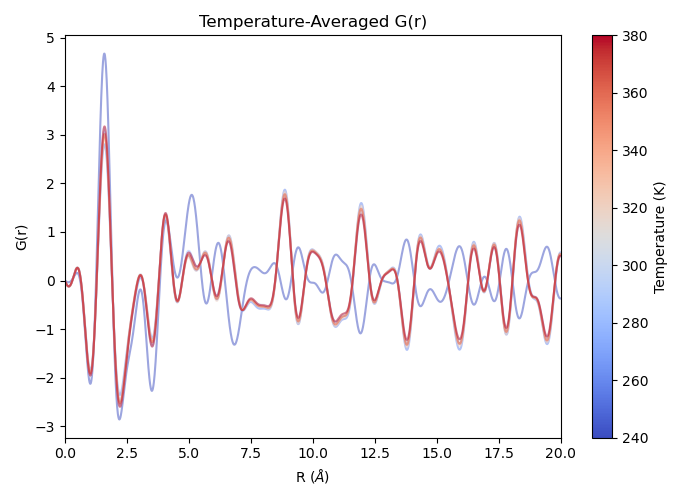

In [14]:
temps = avg_gr_dict["temperature"]   # unique temperatures in K
mean_grs = avg_gr_dict["grs"]

norm = mcolors.Normalize(vmin=temps.min(), vmax=temps.max())
cmap = cm.coolwarm

fig, ax = plt.subplots(figsize=(7, 5))

for i, T in enumerate(temps):
    ax.plot(
        avg_gr_dict["r"],
        mean_grs[i],
        color=cmap(norm(T)),
        alpha=0.5,
        linewidth=1.5,
        label=f"{int(T)} K",
    )

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Temperature (K)")

ax.set_xlabel(r"R ($\AA$)")
ax.set_ylabel("G(r)")
ax.set_xlim(0, 20)
ax.set_title("Temperature-Averaged G(r)")
plt.tight_layout()
plt.show()

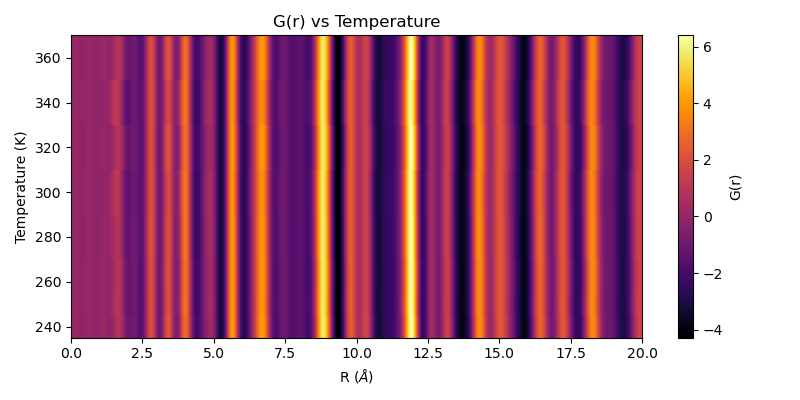

In [32]:
# Heatmap of G(r) vs temperature
plt.figure(figsize=(8, 4))
plt.pcolormesh(
    avg_gr_dict["r"],
    temps,
    mean_grs,
    shading="auto",
    cmap="inferno",
)
plt.colorbar(label="G(r)")
plt.xlabel(r"R ($\AA$)")
plt.ylabel("Temperature (K)")
plt.title("G(r) vs Temperature")
plt.xlim(0, 20)
plt.tight_layout()
plt.show()

## Normalize G(r) (Doesn't do much)

In [20]:
norm_grs = []
for i in range(len(temps)):
    norm_gr = (mean_grs[i] - mean_grs[i].min()) / (mean_grs[i].max() - mean_grs[i].min())
    norm_grs.append(norm_gr)

norm_grs = np.array(norm_grs)

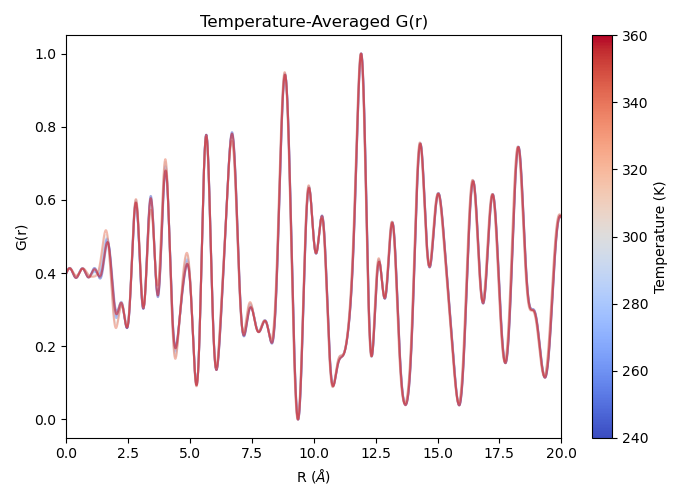

In [21]:

fig, ax = plt.subplots(figsize=(7, 5))

for i, T in enumerate(temps):
    ax.plot(
        avg_gr_dict["r"],
        norm_grs[i],
        color=cmap(norm(T)),
        alpha=0.5,
        linewidth=1.5,
        label=f"{int(T)} K",
    )

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Temperature (K)")

ax.set_xlabel(r"R ($\AA$)")
ax.set_ylabel("G(r)")
ax.set_xlim(0, 20)
ax.set_title("Temperature-Averaged G(r)")
plt.tight_layout()
plt.show()

## Compute dG(r) Relative to a Reference Temperature

Subtract the G(r) at the lowest (or user-chosen) temperature to highlight structural changes.

In [ ]:
# Choose reference temperature (default: lowest T)
REF_TEMP = temps.max()   # change to e.g. 240 to use a specific temperature
#REF_TEMP = 260

ref_idx = np.where(temps == REF_TEMP)[0][0]
reference_gr = norm_grs[ref_idx]

delta_grs = norm_grs - reference_gr   # shape (n_temps, Nr)

print(f"Reference temperature: {int(REF_TEMP)} K")
print(f"dG(r) shape: {delta_grs.shape}")

Reference temperature: 260 K
dG(r) shape: (8, 3001)


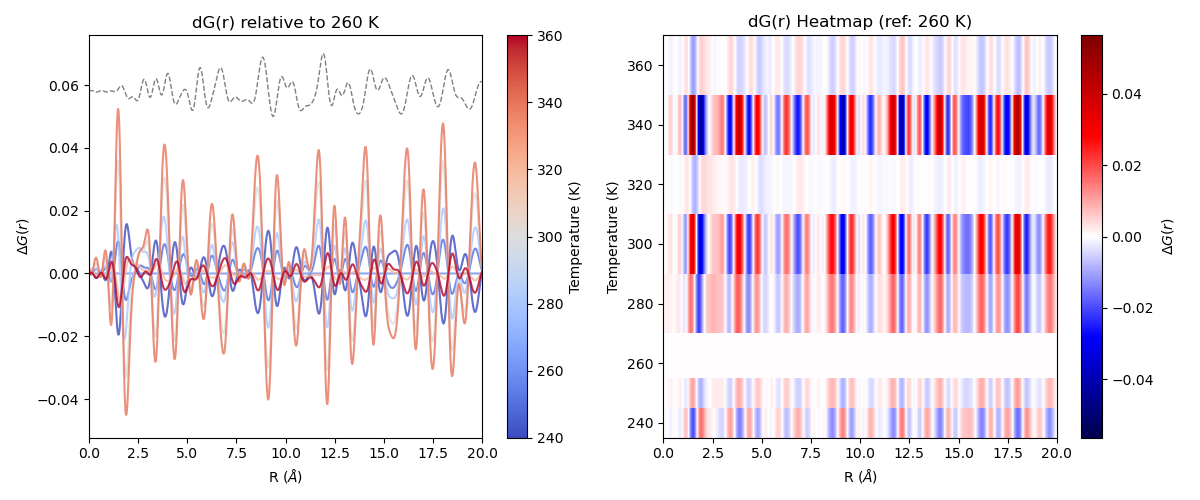

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Waterfall of dG(r) vs temperature
norm_dg = mcolors.Normalize(vmin=temps.min(), vmax=temps.max())
for i, T in enumerate(temps):
    axes[0].plot(
        avg_gr_dict["r"],
        delta_grs[i],
        color=cmap(norm_dg(T)),
        alpha=0.8,
        linewidth=1.5,
        label=f"{int(T)} K",
    )

axes[0].plot(avg_gr_dict["r"], reference_gr/50+0.05, color="gray", linestyle="--", linewidth=1)
sm2 = cm.ScalarMappable(norm=norm_dg, cmap=cmap)
sm2.set_array([])
fig.colorbar(sm2, ax=axes[0], label="Temperature (K)")
axes[0].set_xlabel(r"R ($\AA$)")
axes[0].set_ylabel(r"$\Delta G(r)$")
axes[0].set_xlim(0, 20)
axes[0].set_title(f"dG(r) relative to {int(REF_TEMP)} K")

# Heatmap of dG(r) vs temperature
vmax = np.nanmax(np.abs(delta_grs))
pcm = axes[1].pcolormesh(
    avg_gr_dict["r"],
    temps,
    delta_grs,
    shading="auto",
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
)
fig.colorbar(pcm, ax=axes[1], label=r"$\Delta G(r)$")
axes[1].set_xlabel(r"R ($\AA$)")
axes[1].set_ylabel("Temperature (K)")
axes[1].set_title(f"dG(r) Heatmap (ref: {int(REF_TEMP)} K)")
axes[1].set_xlim(0, 20)

plt.tight_layout()
plt.show()

## Save Averaged G(r) Files (Optional)

In [ ]:
# Uncomment to save each temperature-averaged G(r) to a .gr file
# for i, T in enumerate(avg_gr_dict["temperature"]):
#     out_path = DATA_PATH / f"{SAMPLE_NAME}{int(T)}K_avg.gr"
#     np.savetxt(out_path, np.column_stack((avg_gr_dict["r"], avg_gr_dict["grs"][i])),
#                header="r\tG(r)", comments="# ")
#     print(f"Saved: {out_path.name}")